In [77]:
from matplotlib.pylab import plt
import numpy as np
import cv2

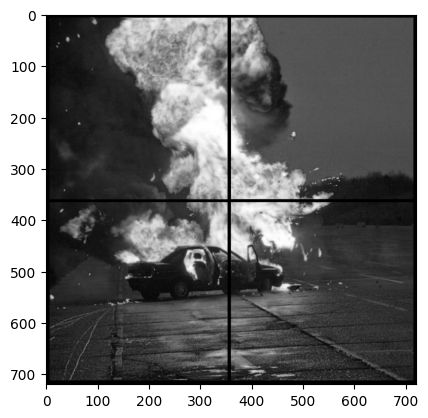

In [78]:
meledak = plt.imread('Assets/meledak.png')
aktivis = cv2.cvtColor(asset, cv2.COLOR_BGR2GRAY)
plt.imshow(aktivis, cmap = 'gray')

(720, 720, 3)
(350, 350)
(350, 350)
(345, 350)
(345, 355)


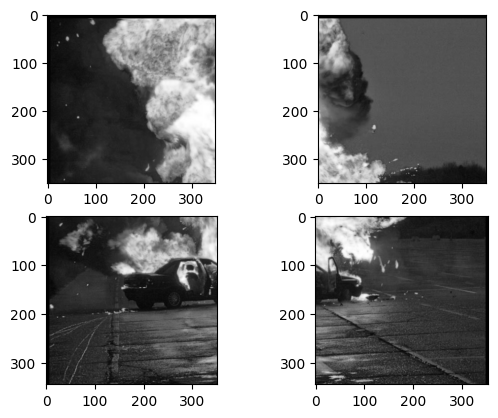

In [107]:
meledak.shape
citra1 = meledak [0:350, 0:350]
citra1 = cv2.cvtColor(citra1, cv2.COLOR_BGR2GRAY)
plt.subplot(2, 2, 1)
plt.imshow(citra1, cmap = 'gray')

citra2 = meledak [0:350, 365:715]
citra2 = cv2.cvtColor(citra2, cv2.COLOR_BGR2GRAY)
plt.subplot(2, 2, 2)
plt.imshow(citra2, cmap = 'gray')

citra3 = meledak [365:710, 0:350]
citra3 = cv2.cvtColor(citra3, cv2.COLOR_BGR2GRAY)
plt.subplot(2, 2, 3)
plt.imshow(citra3, cmap = 'gray')

citra4 = meledak [365:710, 365:720]
citra4 = cv2.cvtColor(citra4, cv2.COLOR_BGR2GRAY)
plt.subplot(2, 2, 4)
plt.imshow(citra4, cmap = 'gray')
print(meledak.shape)
print(citra1.shape)
print(citra2.shape)
print(citra3.shape)
print(citra4.shape)
plt.show()

In [108]:
def fungsi_dua_b(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

# Tipe c: penyatuan sumbu vertikal
def fungsi_dua_c(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

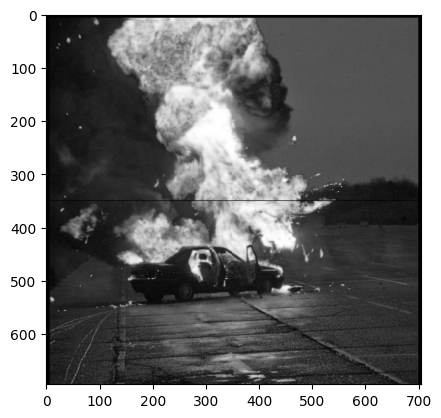

In [109]:
merger1 = fungsi_dua_b (citra1, citra2)
merger2 = fungsi_dua_b (citra3, citra4)
mergered = fungsi_dua_c (merger1, merger2)

plt.imshow(mergered, cmap='gray')
plt.show()

In [ ]:
def ekualisasi(citra): 
    height, width = citra.shape 
 
    # 1. Hitung histogram citra
    hist = np.zeros(256, dtype=int) 
    for i in range(height):
        for j in range(width):
            pixel_value = citra[i, j]
            hist[pixel_value] += 1
 
    # 2. Hitung CDF
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0] 
    for k in range(1, 256):
        cdf[k] = cdf[k-1] + hist[k]
 
    # 3. Normalisasi CDF ke rentang 0-255
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8) 
 
    # 4. Terapkan hasil normalisasi ke setiap pixel
    hasil = np.zeros_like(citra, dtype=np.uint8) 
    for i in range(height):
        for j in range(width):
            # Nilai pixel lama menjadi index untuk mengambil nilai baru dari cdf_normal
            hasil[i, j] = cdf_normal[citra[i, j]]
 
    return hasil